In [1]:
import pandas as pd; pd.set_option('display.max_columns', 100)
import numpy as np

from tqdm.notebook import tqdm

import matplotlib.pyplot as plt; plt.style.use('ggplot')
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split, GridSearchCV, RepeatedKFold, RepeatedStratifiedKFold
from sklearn.metrics import log_loss
from sklearn.inspection import PartialDependenceDisplay
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


# READING THE DATA FILES

In [2]:
train = pd.read_csv('../input/icr-identify-age-related-conditions/train.csv')
test = pd.read_csv('../input/icr-identify-age-related-conditions/test.csv')

In [3]:
train_features = train.columns
test_features = test.columns

In [4]:
def determine_feature_type(data, feature):
    # Get the data type of the feature
    feature_type = data[feature].dtype
    
    # Check if the data type is object or category (indicating categorical data)
    if feature_type == 'object' or feature_type.name == 'category':
        return 'Categorical'
    else:
        return 'Numerical'
# Specify the name of the feature you want to determine the type for
for feature_name in train_features:
    
    # Determine the type of the feature
    feature_type = determine_feature_type(train, feature_name)

    print(f"The feature '{feature_name}' is: {feature_type}")

The feature 'Id' is: Categorical
The feature 'AB' is: Numerical
The feature 'AF' is: Numerical
The feature 'AH' is: Numerical
The feature 'AM' is: Numerical
The feature 'AR' is: Numerical
The feature 'AX' is: Numerical
The feature 'AY' is: Numerical
The feature 'AZ' is: Numerical
The feature 'BC' is: Numerical
The feature 'BD ' is: Numerical
The feature 'BN' is: Numerical
The feature 'BP' is: Numerical
The feature 'BQ' is: Numerical
The feature 'BR' is: Numerical
The feature 'BZ' is: Numerical
The feature 'CB' is: Numerical
The feature 'CC' is: Numerical
The feature 'CD ' is: Numerical
The feature 'CF' is: Numerical
The feature 'CH' is: Numerical
The feature 'CL' is: Numerical
The feature 'CR' is: Numerical
The feature 'CS' is: Numerical
The feature 'CU' is: Numerical
The feature 'CW ' is: Numerical
The feature 'DA' is: Numerical
The feature 'DE' is: Numerical
The feature 'DF' is: Numerical
The feature 'DH' is: Numerical
The feature 'DI' is: Numerical
The feature 'DL' is: Numerical
The

THIS SHOWS THAT WE HAVE ONLY 2 CATEGORICAL FEATURES , ID AND 'EJ'

From above, carefully notice the ' ' are weirdly placed for some features, this can create issues when dealing with plotting and fetching data

The feature 'BD ' should be 'BD'
The feature 'FD ' should be 'FD'
The feature 'CD ' should be 'CD'

This can be tackled using the code below

In [5]:
names = test.columns.tolist()
test_features = [x.replace(' ', '') for x in names]
test.columns = test_features

names1 = train.columns.tolist()
train_features = [x.replace(' ', '') for x in names1]
train.columns = train_features

# ONR HOT ENCODING THE CATEGORICAL VALUES

In [6]:
train['EJ'].value_counts()

B    395
A    222
Name: EJ, dtype: int64

In [7]:
train['EJ'] = train['EJ'].map({'A': 0, 'B': 1})
test['EJ'] = test['EJ'].map({'A': 0, 'B': 1})

In [8]:
greeks =pd.read_csv('../input/icr-identify-age-related-conditions/greeks.csv')
submission = pd.read_csv('../input/icr-identify-age-related-conditions/sample_submission.csv')

print('The dimension of the train dataset is:', train.shape)
print('The dimension of the test dataset is:', test.shape)
print('The dimension of the greeks dataset is:', greeks.shape)
print('The dimension of the submission dataset is:', submission.shape)


The dimension of the train dataset is: (617, 58)
The dimension of the test dataset is: (5, 57)
The dimension of the greeks dataset is: (617, 6)
The dimension of the submission dataset is: (5, 3)


# EDA

<AxesSubplot: xlabel='Class', ylabel='count'>

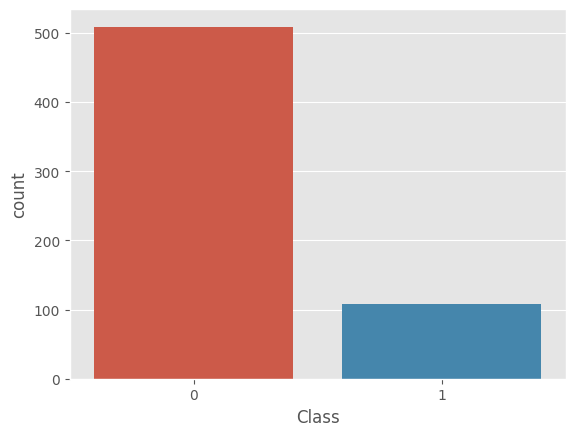

In [9]:
sns.countplot(data = train, x = 'Class')

DATA SET IS HEAVILY IMBALANCED, WE HAVE TO USE VARIOUS TECHNIQUES TO CATER RHIS IN MODELLING

* #  Distributions of all features w.r.t. their classes

# For features starting with letter "A"

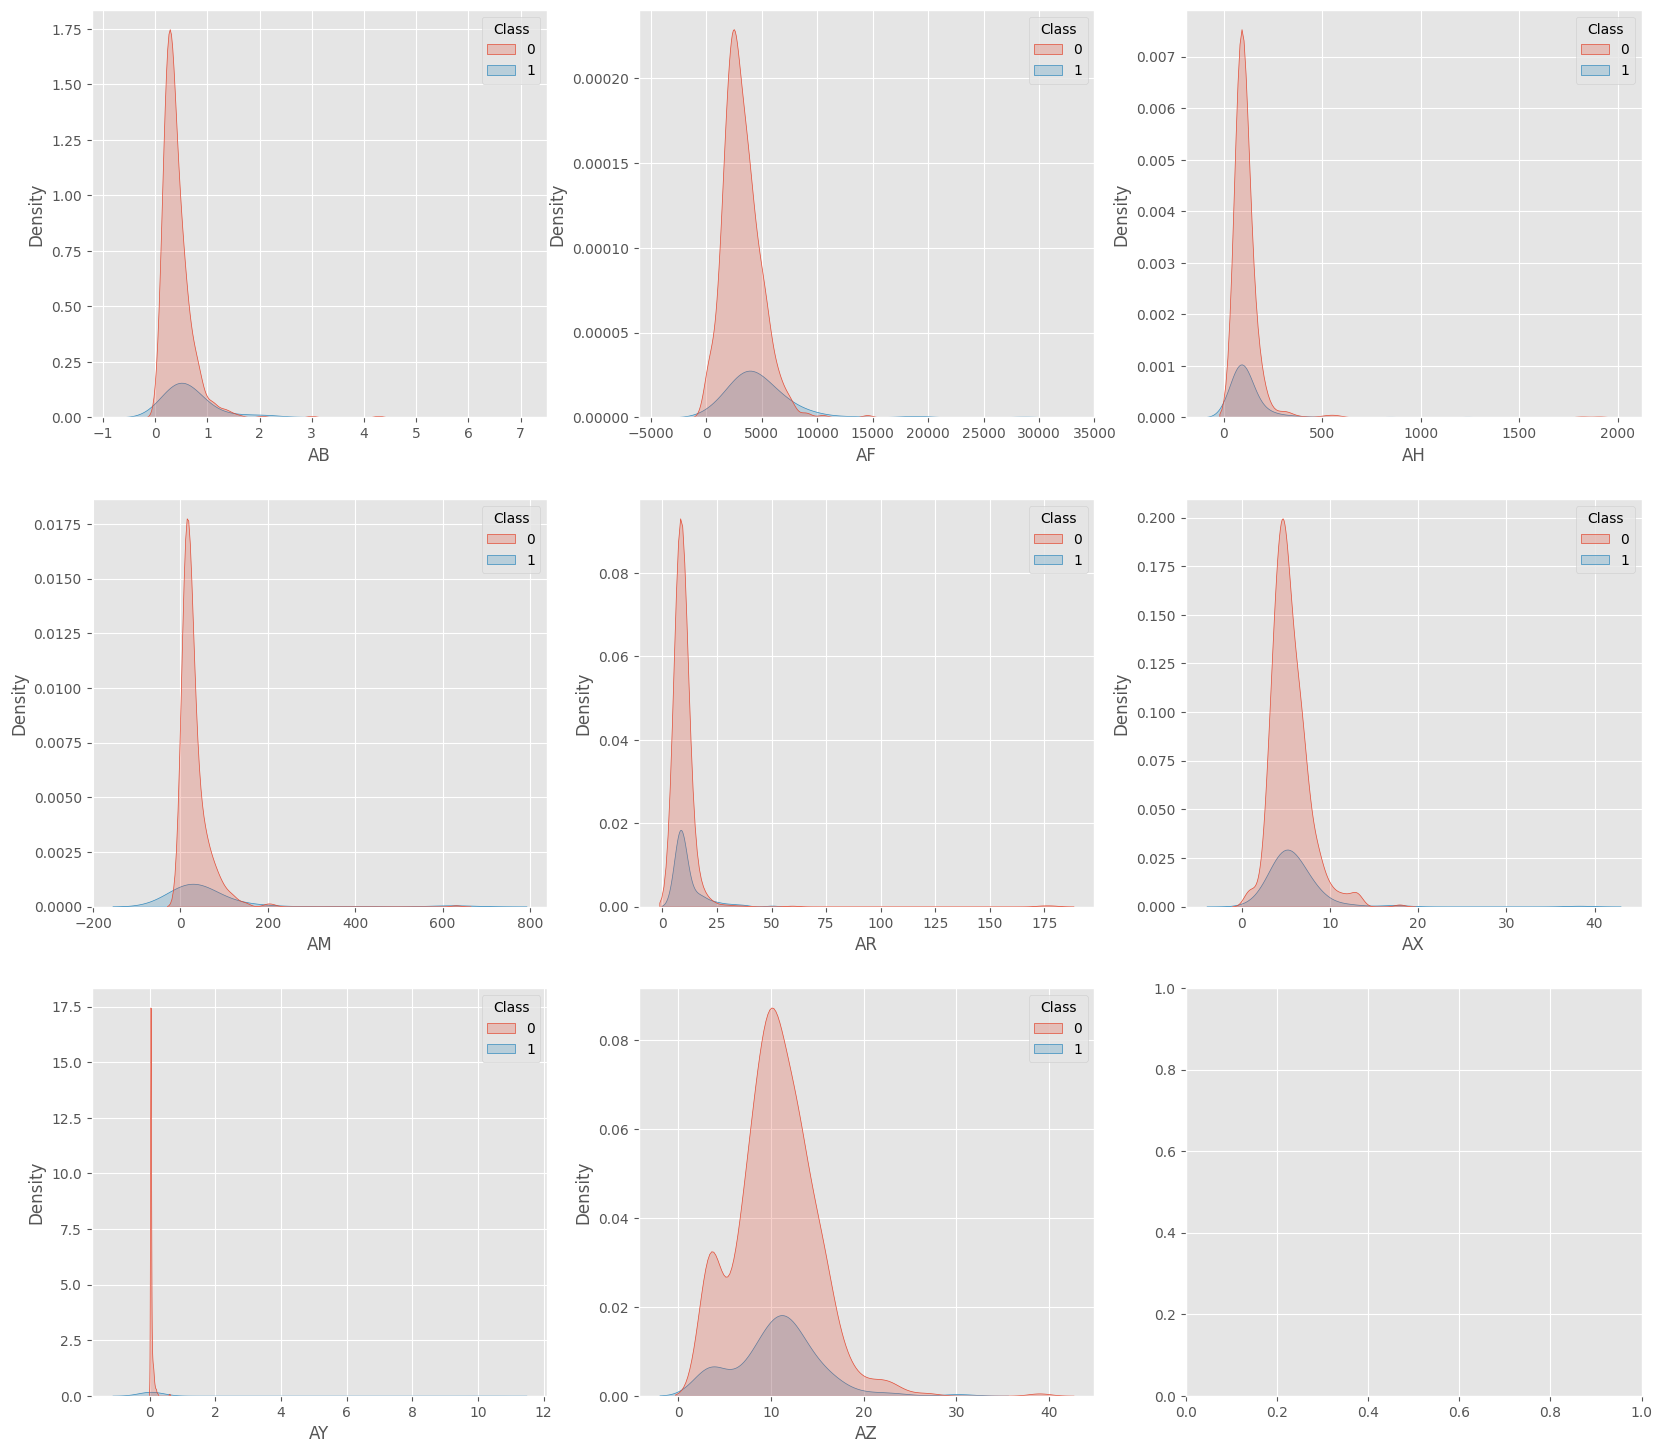

In [10]:
fig, axes = plt.subplots(3, 3, figsize = (20, 18))
sns.kdeplot(ax = axes[0, 0], x = 'AB', hue = 'Class', data = train, fill = True)
sns.kdeplot(ax = axes[0, 1], x = 'AF', hue = 'Class', data = train, fill = True)
sns.kdeplot(ax = axes[0, 2], x = 'AH', hue = 'Class', data = train, fill = True)
sns.kdeplot(ax = axes[1, 0], x = 'AM', hue = 'Class', data = train, fill = True)
sns.kdeplot(ax = axes[1, 1], x = 'AR', hue = 'Class', data = train, fill = True)
sns.kdeplot(ax = axes[1, 2], x = 'AX', hue = 'Class', data = train, fill = True)
sns.kdeplot(ax = axes[2, 0], x = 'AY', hue = 'Class', data = train, fill = True)
sns.kdeplot(ax = axes[2, 1], x = 'AZ', hue = 'Class', data = train, fill = True);

# For features starting with letter "B"

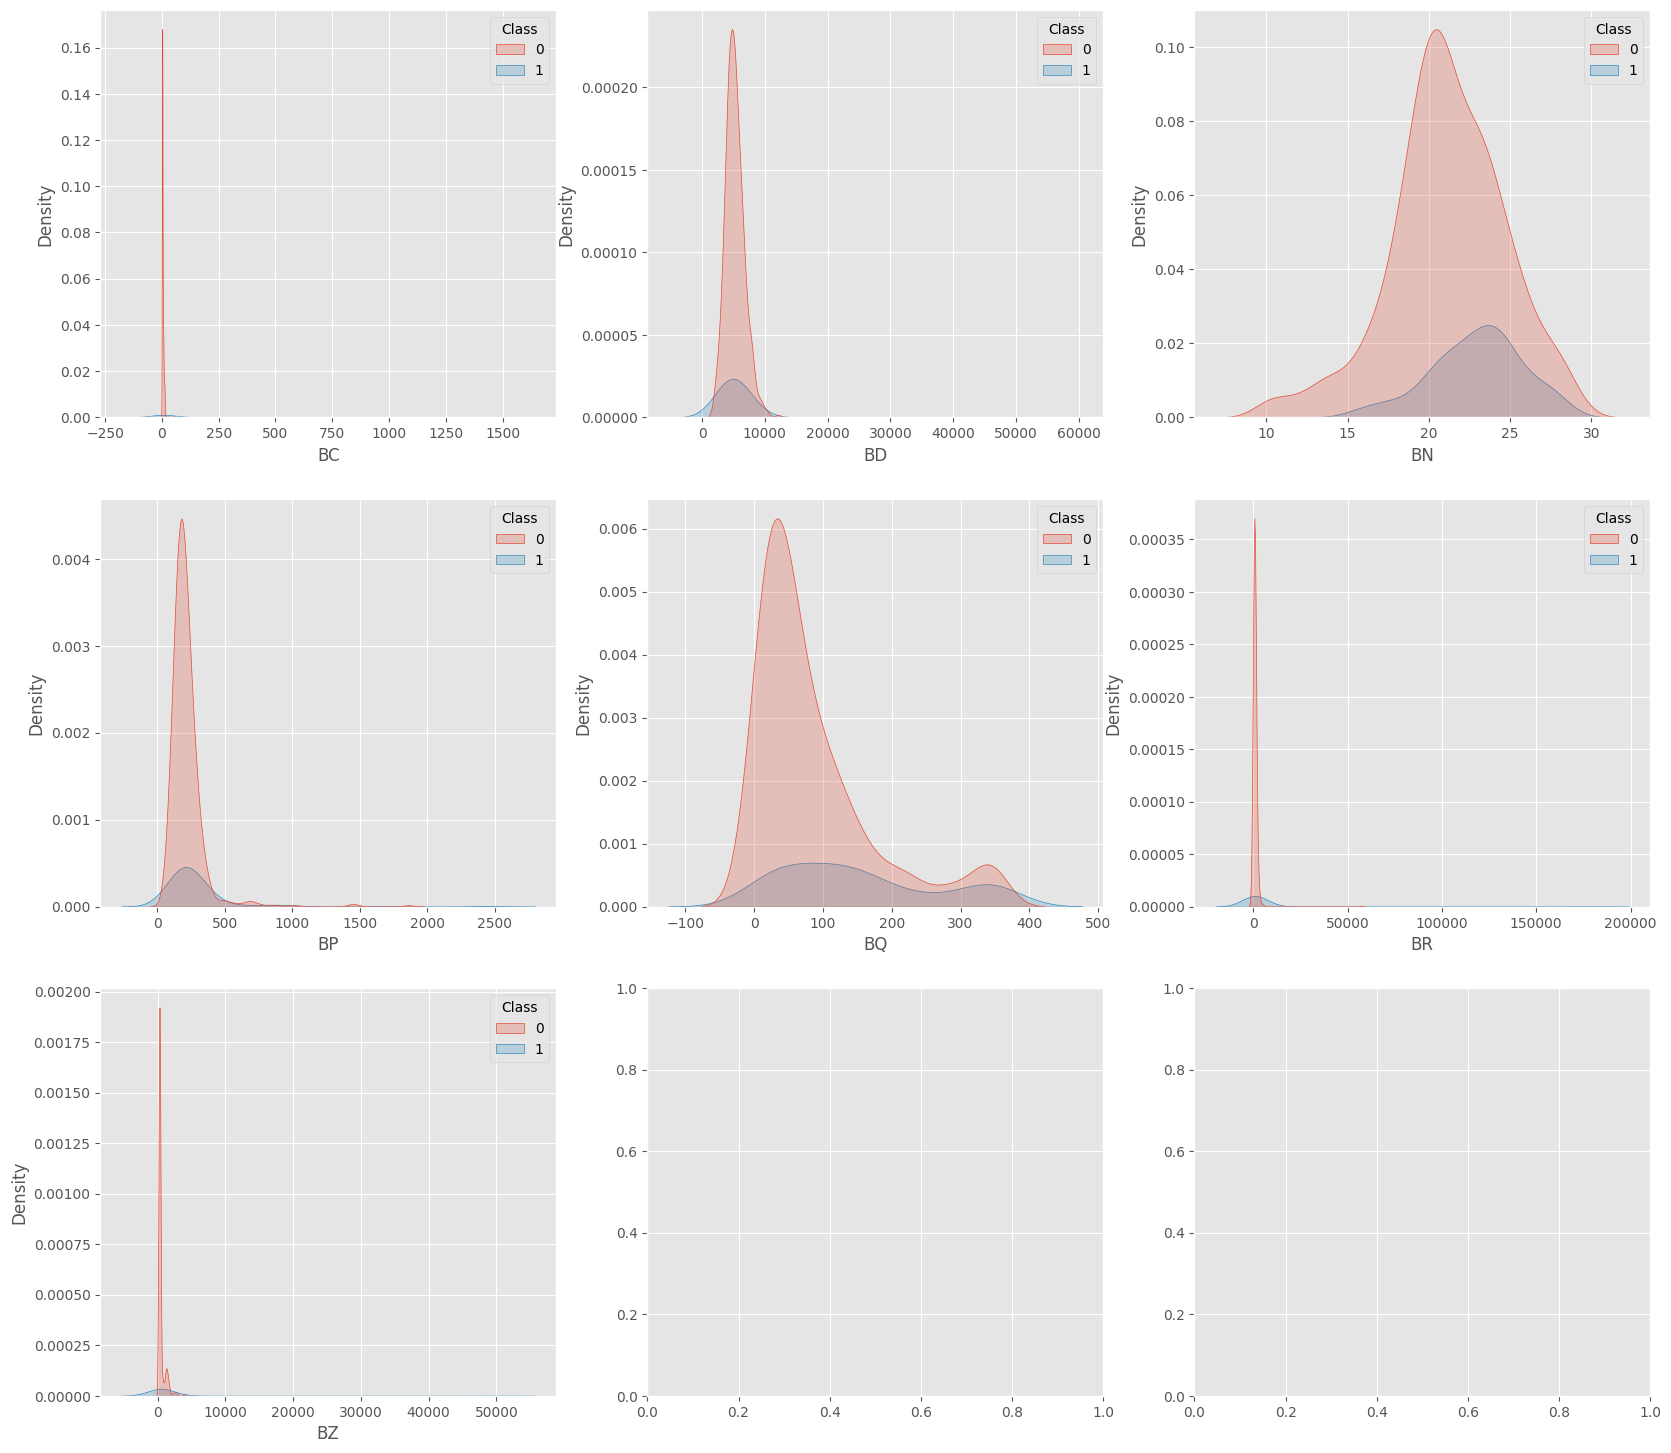

In [11]:
fig, axes = plt.subplots(3, 3, figsize = (20, 18))

sns.kdeplot(ax = axes[0, 0], x = 'BC', hue = 'Class', data = train, fill = True)
sns.kdeplot(ax = axes[0, 1], x = 'BD', hue = 'Class', data = train, fill = True)
sns.kdeplot(ax = axes[0, 2], x = 'BN', hue = 'Class', data = train, fill = True)
sns.kdeplot(ax = axes[1, 0], x = 'BP', hue = 'Class', data = train, fill = True)
sns.kdeplot(ax = axes[1, 1], x = 'BQ', hue = 'Class', data = train, fill = True)
sns.kdeplot(ax = axes[1, 2], x = 'BR', hue = 'Class', data = train, fill = True)
sns.kdeplot(ax = axes[2, 0], x = 'BZ', hue = 'Class', data = train, fill = True);

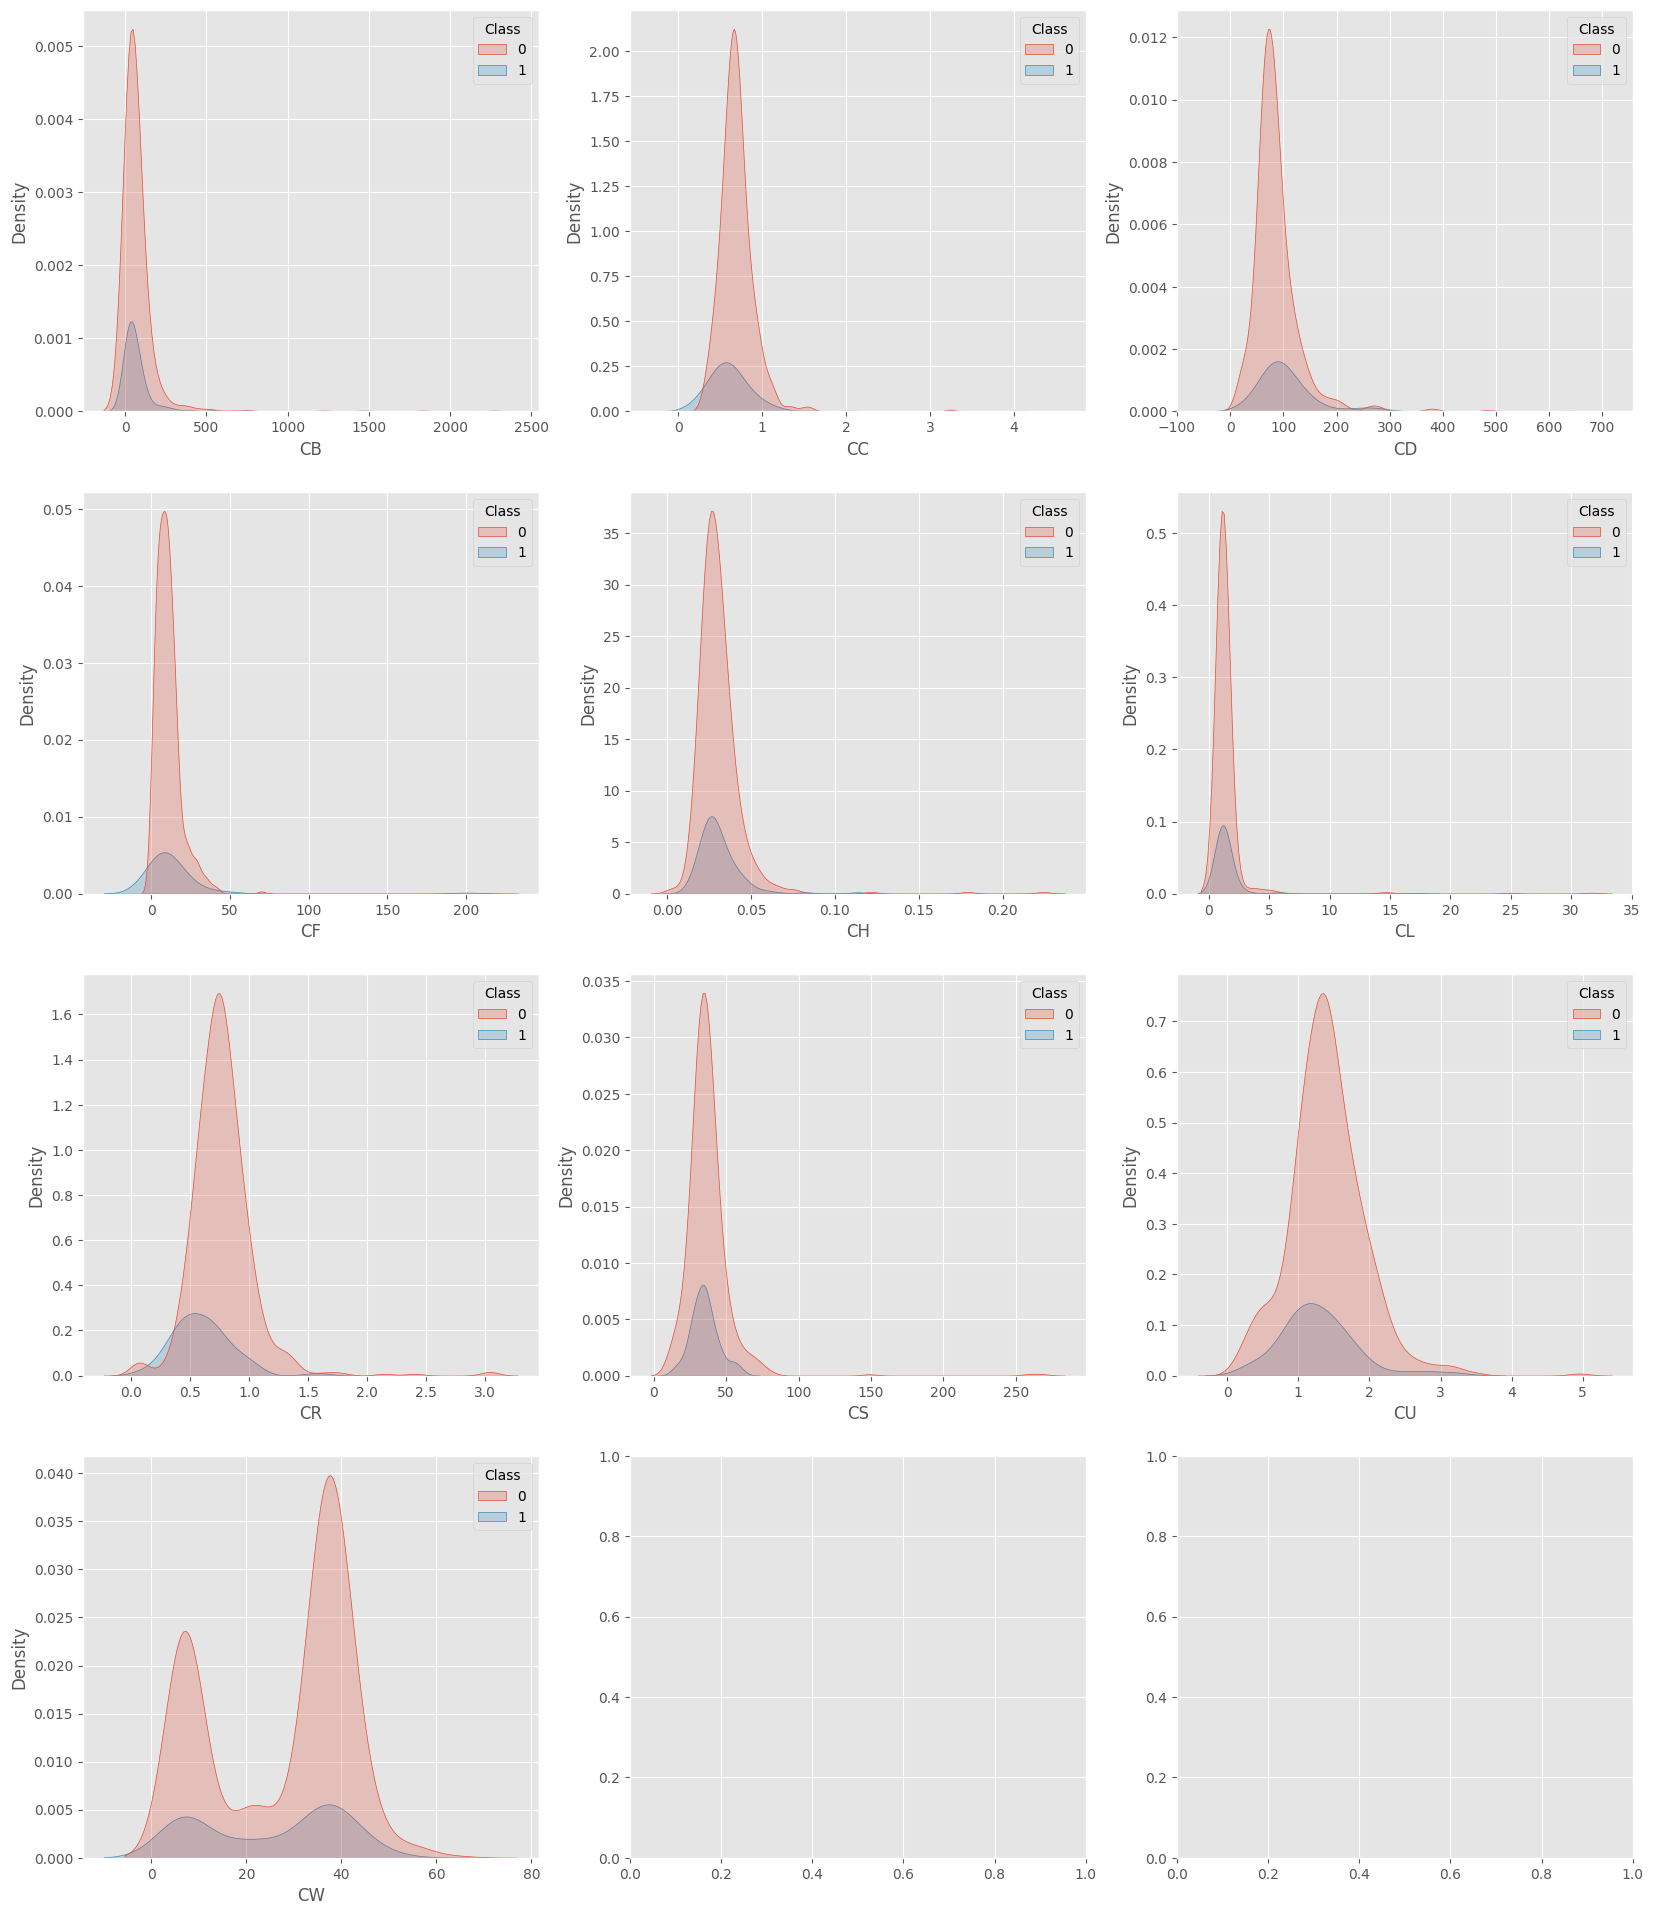

In [12]:
fig, axes = plt.subplots(4, 3, figsize = (20, 24))

sns.kdeplot(ax = axes[0, 0], x = 'CB', hue = 'Class', data = train, fill = True)
sns.kdeplot(ax = axes[0, 1], x = 'CC', hue = 'Class', data = train, fill = True)
sns.kdeplot(ax = axes[0, 2], x = 'CD', hue = 'Class', data = train, fill = True)
sns.kdeplot(ax = axes[1, 0], x = 'CF', hue = 'Class', data = train, fill = True)
sns.kdeplot(ax = axes[1, 1], x = 'CH', hue = 'Class', data = train, fill = True)
sns.kdeplot(ax = axes[1, 2], x = 'CL', hue = 'Class', data = train, fill = True)
sns.kdeplot(ax = axes[2, 0], x = 'CR', hue = 'Class', data = train, fill = True)
sns.kdeplot(ax = axes[2, 1], x = 'CS', hue = 'Class', data = train, fill = True)
sns.kdeplot(ax = axes[2, 2], x = 'CU', hue = 'Class', data = train, fill = True)
sns.kdeplot(ax = axes[3, 0], x = 'CW', hue = 'Class', data = train, fill = True);

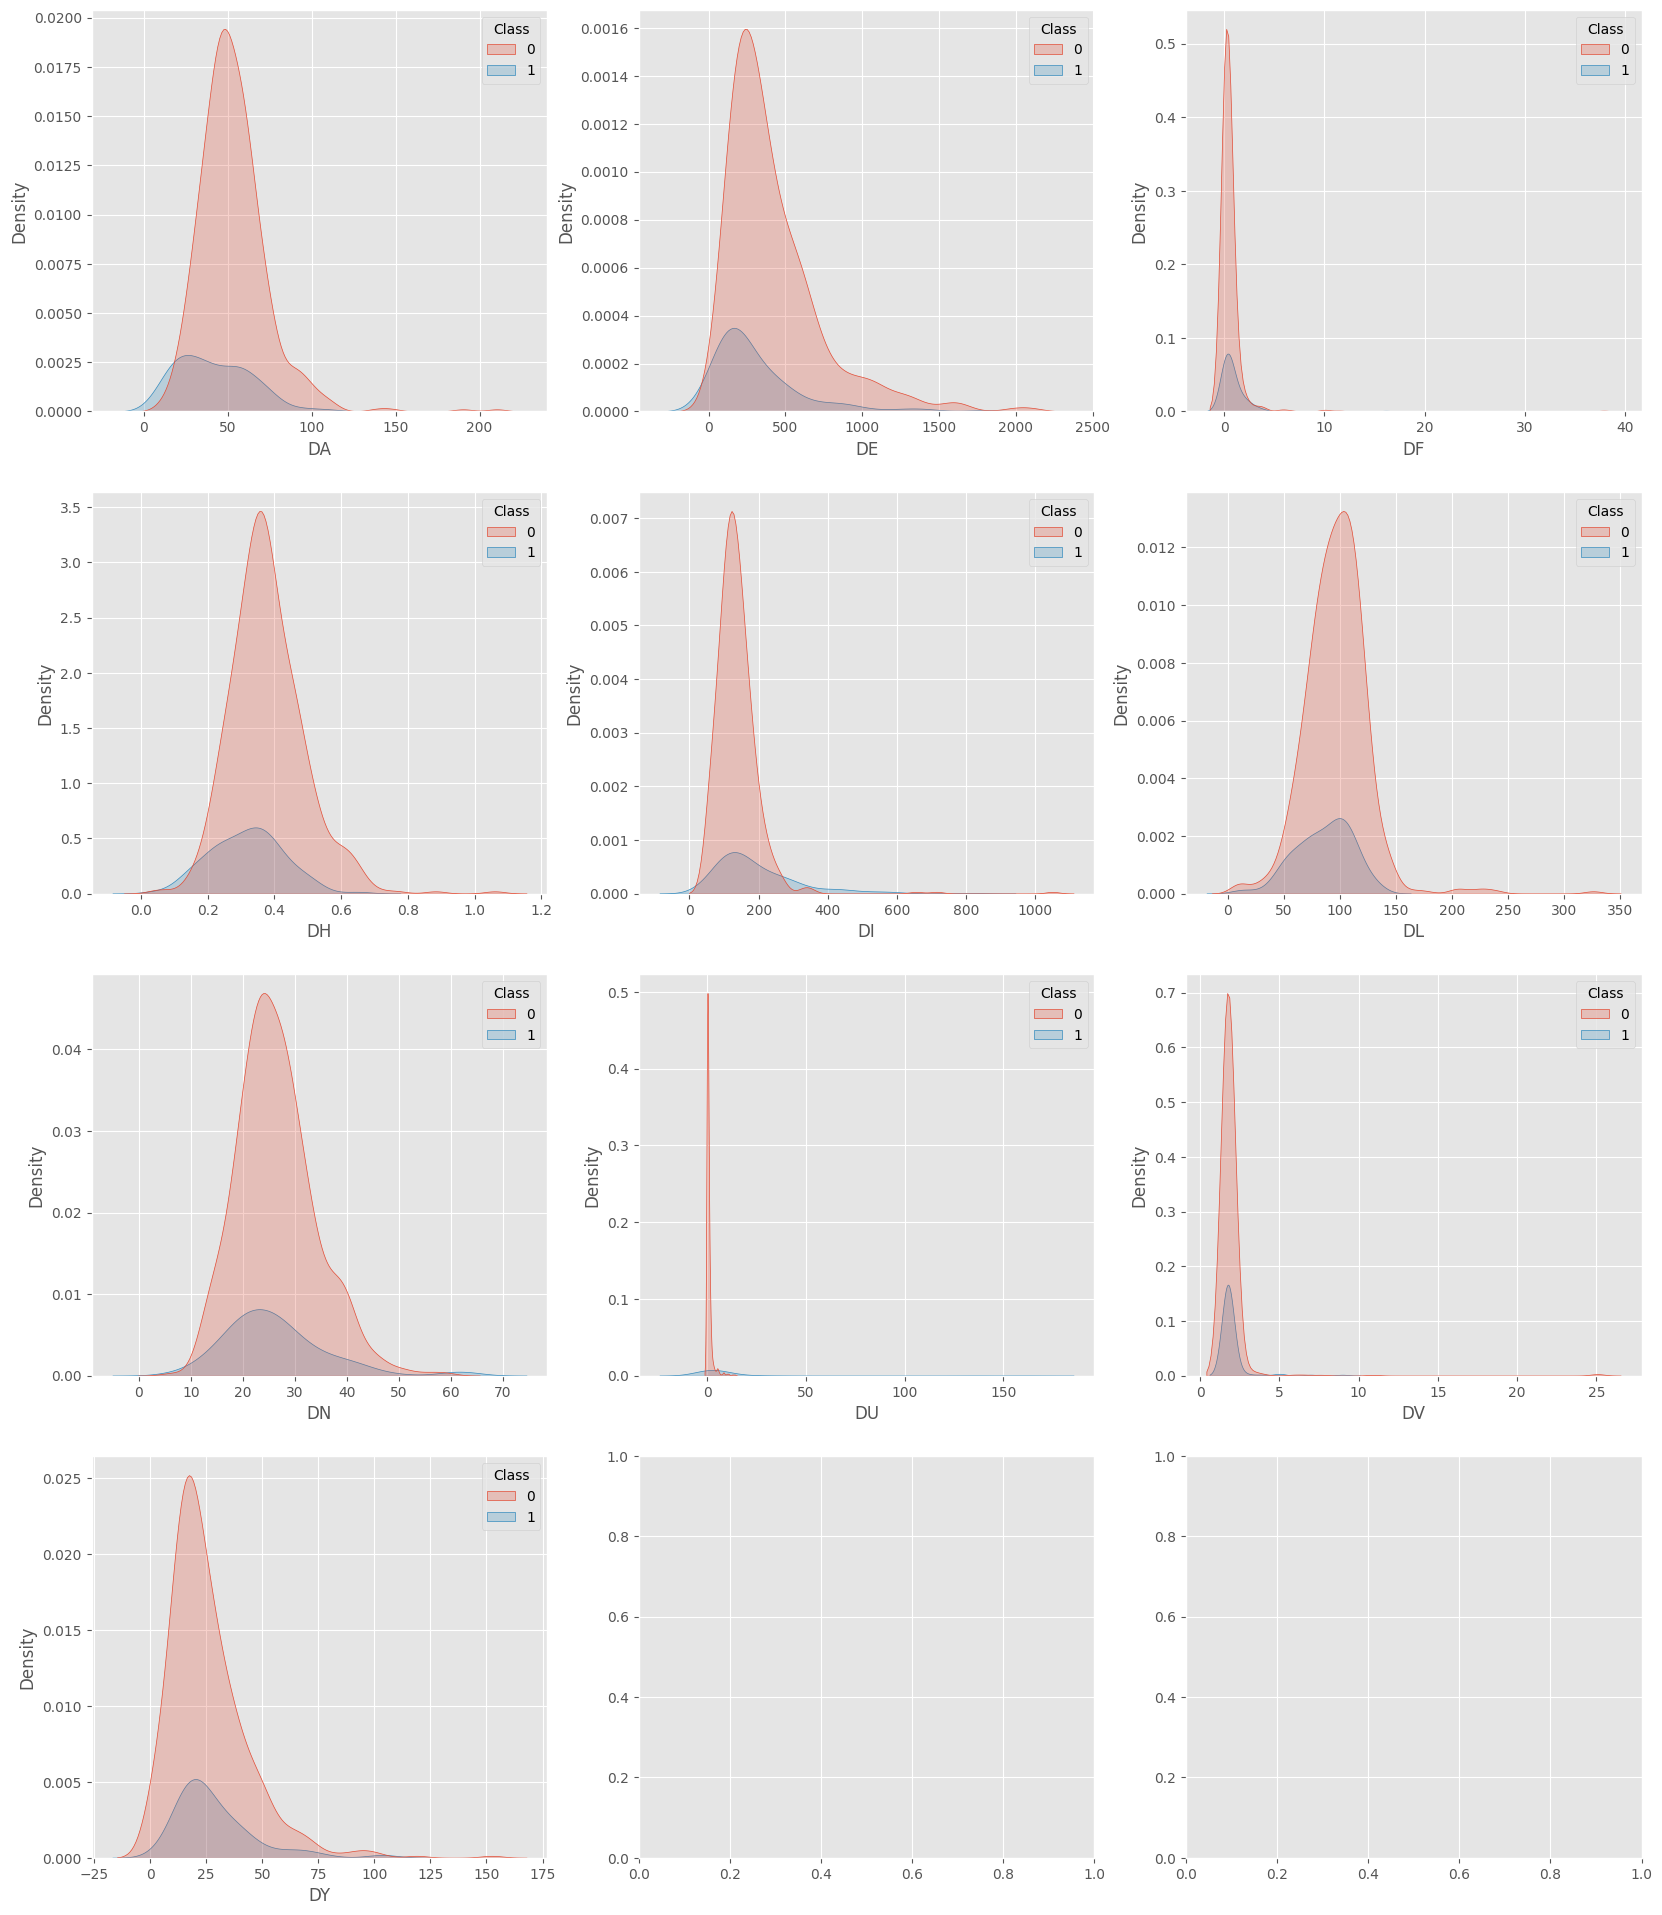

In [13]:
fig, axes = plt.subplots(4, 3, figsize = (20, 24))

sns.kdeplot(ax = axes[0, 0], x = 'DA', hue = 'Class', data = train, fill = True)
sns.kdeplot(ax = axes[0, 1], x = 'DE', hue = 'Class', data = train, fill = True)
sns.kdeplot(ax = axes[0, 2], x = 'DF', hue = 'Class', data = train, fill = True)
sns.kdeplot(ax = axes[1, 0], x = 'DH', hue = 'Class', data = train, fill = True)
sns.kdeplot(ax = axes[1, 1], x = 'DI', hue = 'Class', data = train, fill = True)
sns.kdeplot(ax = axes[1, 2], x = 'DL', hue = 'Class', data = train, fill = True)
sns.kdeplot(ax = axes[2, 0], x = 'DN', hue = 'Class', data = train, fill = True)
sns.kdeplot(ax = axes[2, 1], x = 'DU', hue = 'Class', data = train, fill = True)
sns.kdeplot(ax = axes[2, 2], x = 'DV', hue = 'Class', data = train, fill = True)
sns.kdeplot(ax = axes[3, 0], x = 'DY', hue = 'Class', data = train, fill = True);

<AxesSubplot: xlabel='EU', ylabel='Density'>

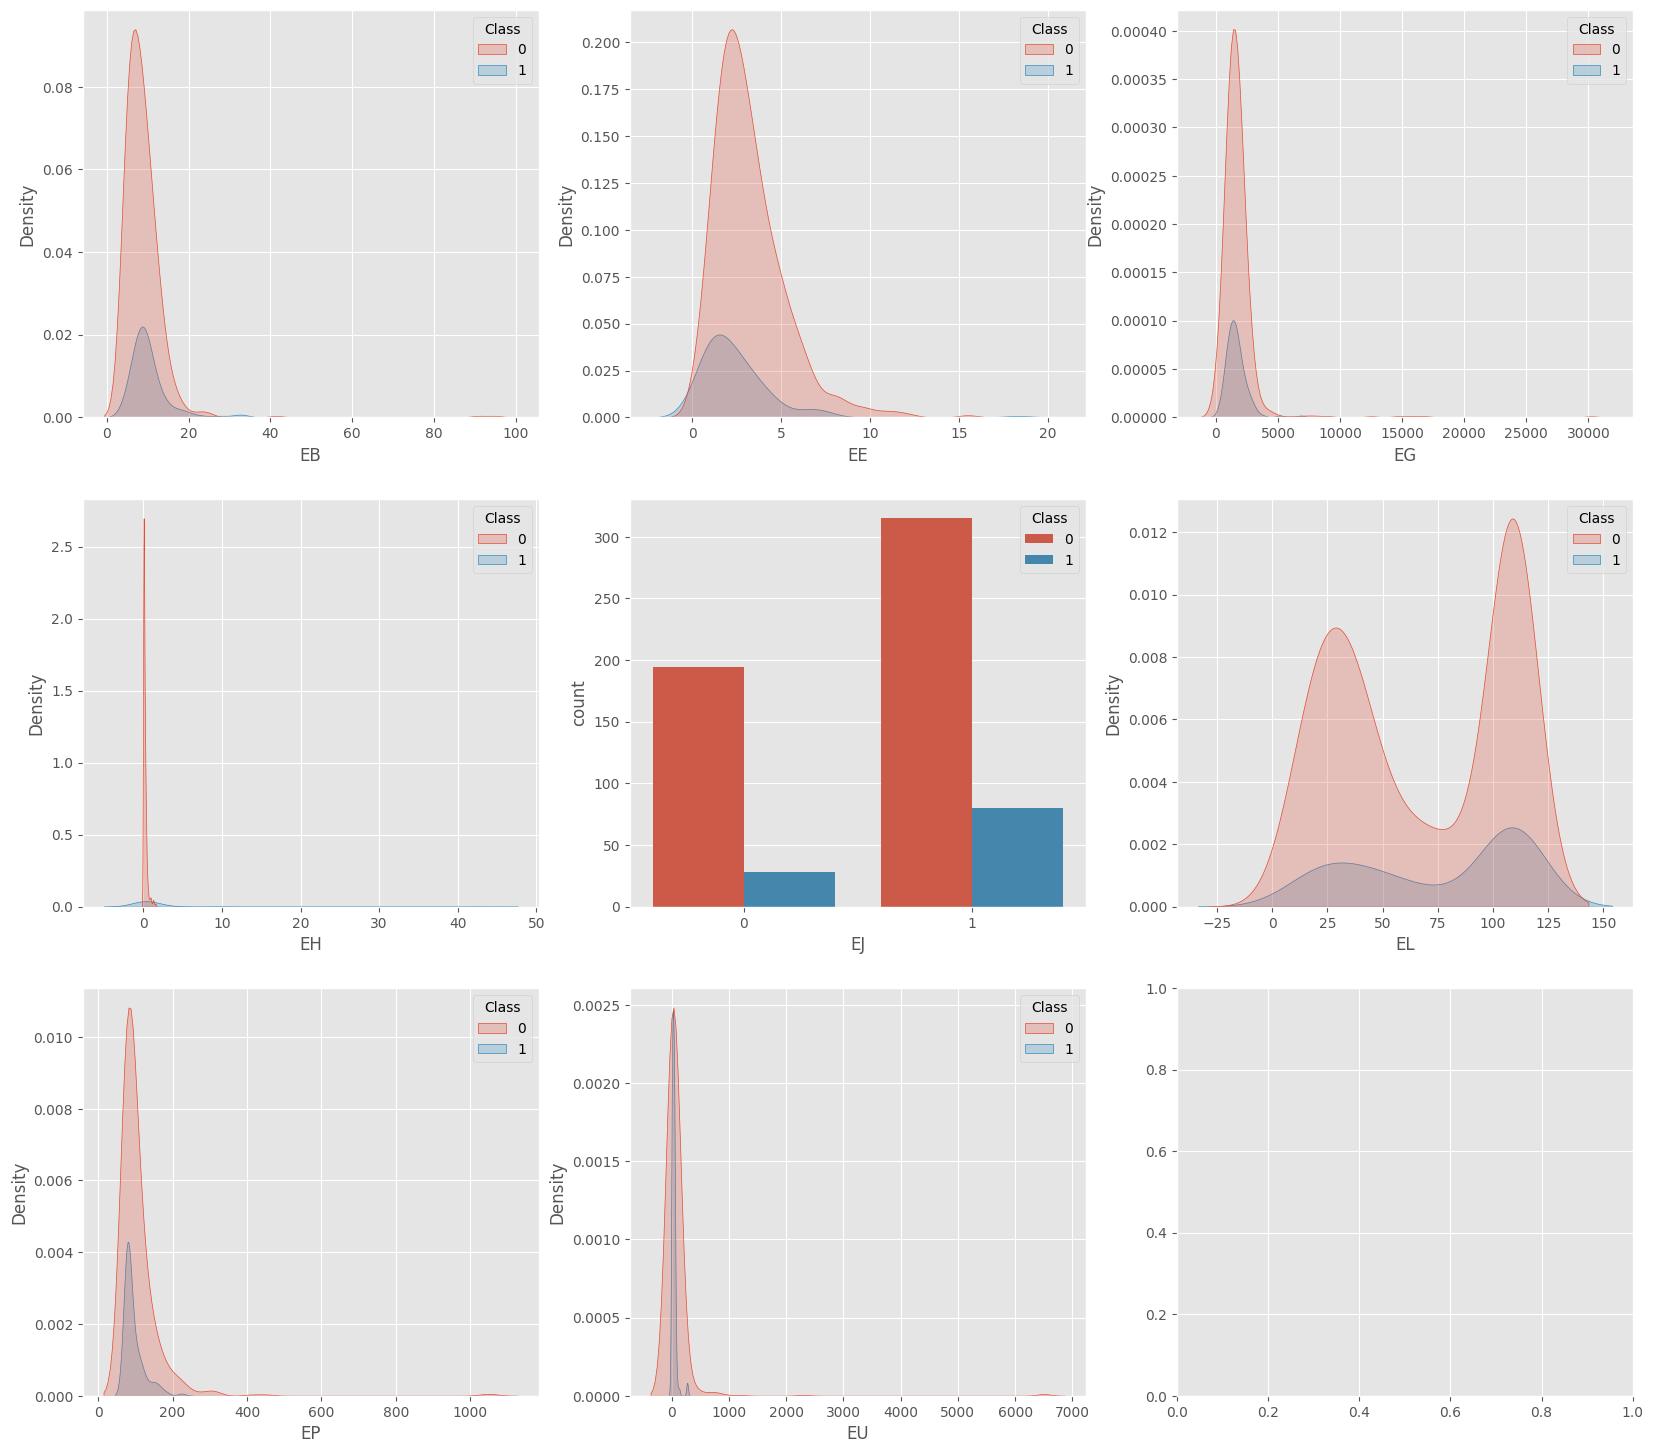

In [14]:
fig, axes = plt.subplots(3, 3, figsize = (20, 18))

sns.kdeplot(ax = axes[0, 0], x = 'EB', hue = 'Class', data = train, fill = True)
sns.kdeplot(ax = axes[0, 1], x = 'EE', hue = 'Class', data = train, fill = True)
sns.kdeplot(ax = axes[0, 2], x = 'EG', hue = 'Class', data = train, fill = True)
sns.kdeplot(ax = axes[1, 0], x = 'EH', hue = 'Class', data = train, fill = True)
sns.countplot(ax = axes[1, 1], x = 'EJ', hue = 'Class', data = train)
sns.kdeplot(ax = axes[1, 2], x = 'EL', hue = 'Class', data = train, fill = True)
sns.kdeplot(ax = axes[2, 0], x = 'EP', hue = 'Class', data = train, fill = True)
sns.kdeplot(ax = axes[2, 1], x = 'EU', hue = 'Class', data = train, fill = True)

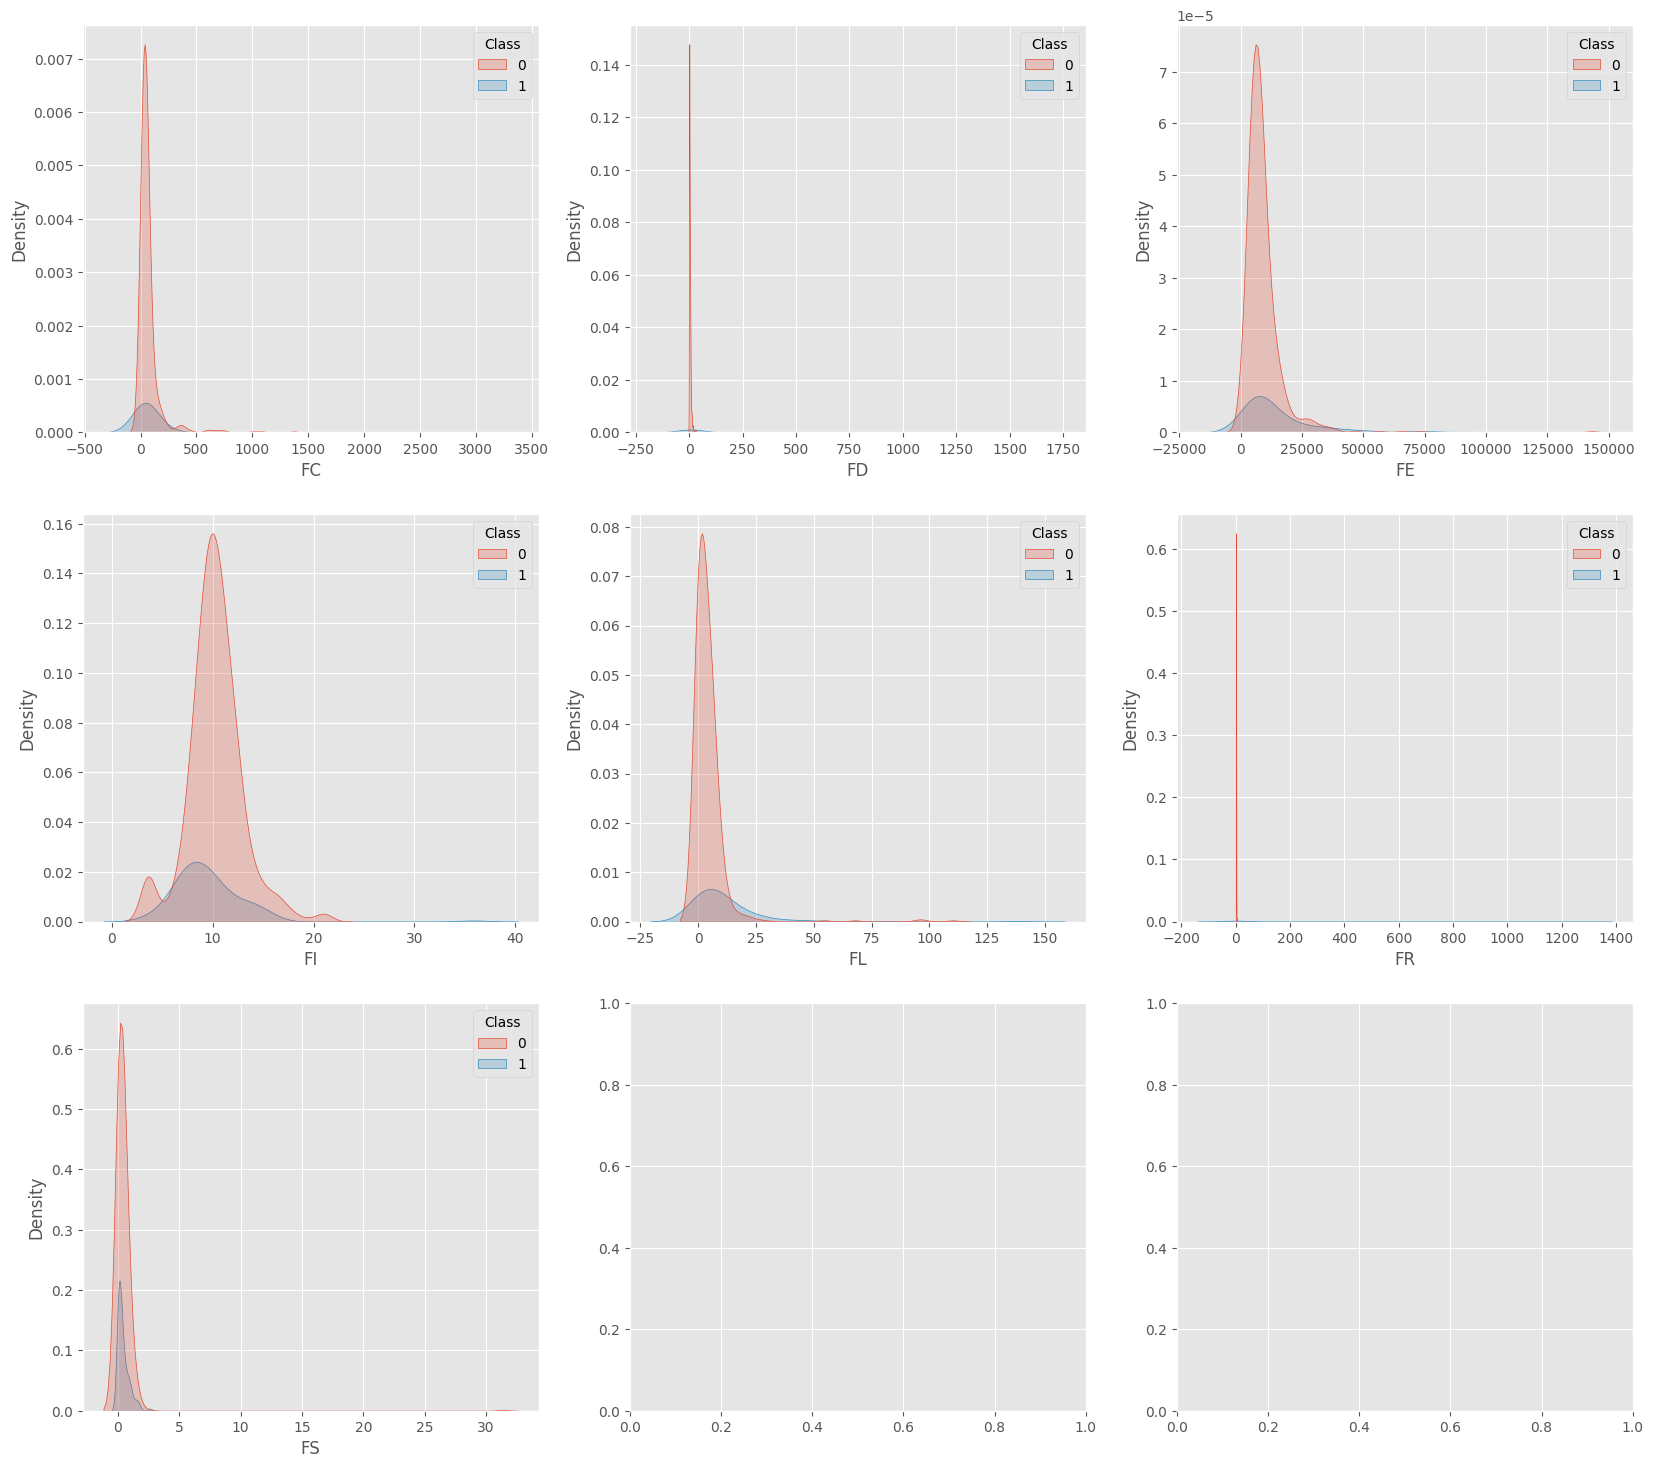

In [15]:
fig, axes = plt.subplots(3, 3, figsize = (20, 18))

sns.kdeplot(ax = axes[0, 0], x = 'FC', hue = 'Class', data = train, fill = True)
sns.kdeplot(ax = axes[0, 1], x = 'FD', hue = 'Class', data = train, fill = True)
sns.kdeplot(ax = axes[0, 2], x = 'FE', hue = 'Class', data = train, fill = True)
sns.kdeplot(ax = axes[1, 0], x = 'FI', hue = 'Class', data = train, fill = True)
sns.kdeplot(ax = axes[1, 1], x = 'FL', hue = 'Class', data = train, fill = True)
sns.kdeplot(ax = axes[1, 2], x = 'FR', hue = 'Class', data = train, fill = True)
sns.kdeplot(ax = axes[2, 0], x = 'FS', hue = 'Class', data = train, fill = True);

<AxesSubplot: xlabel='GL', ylabel='Density'>

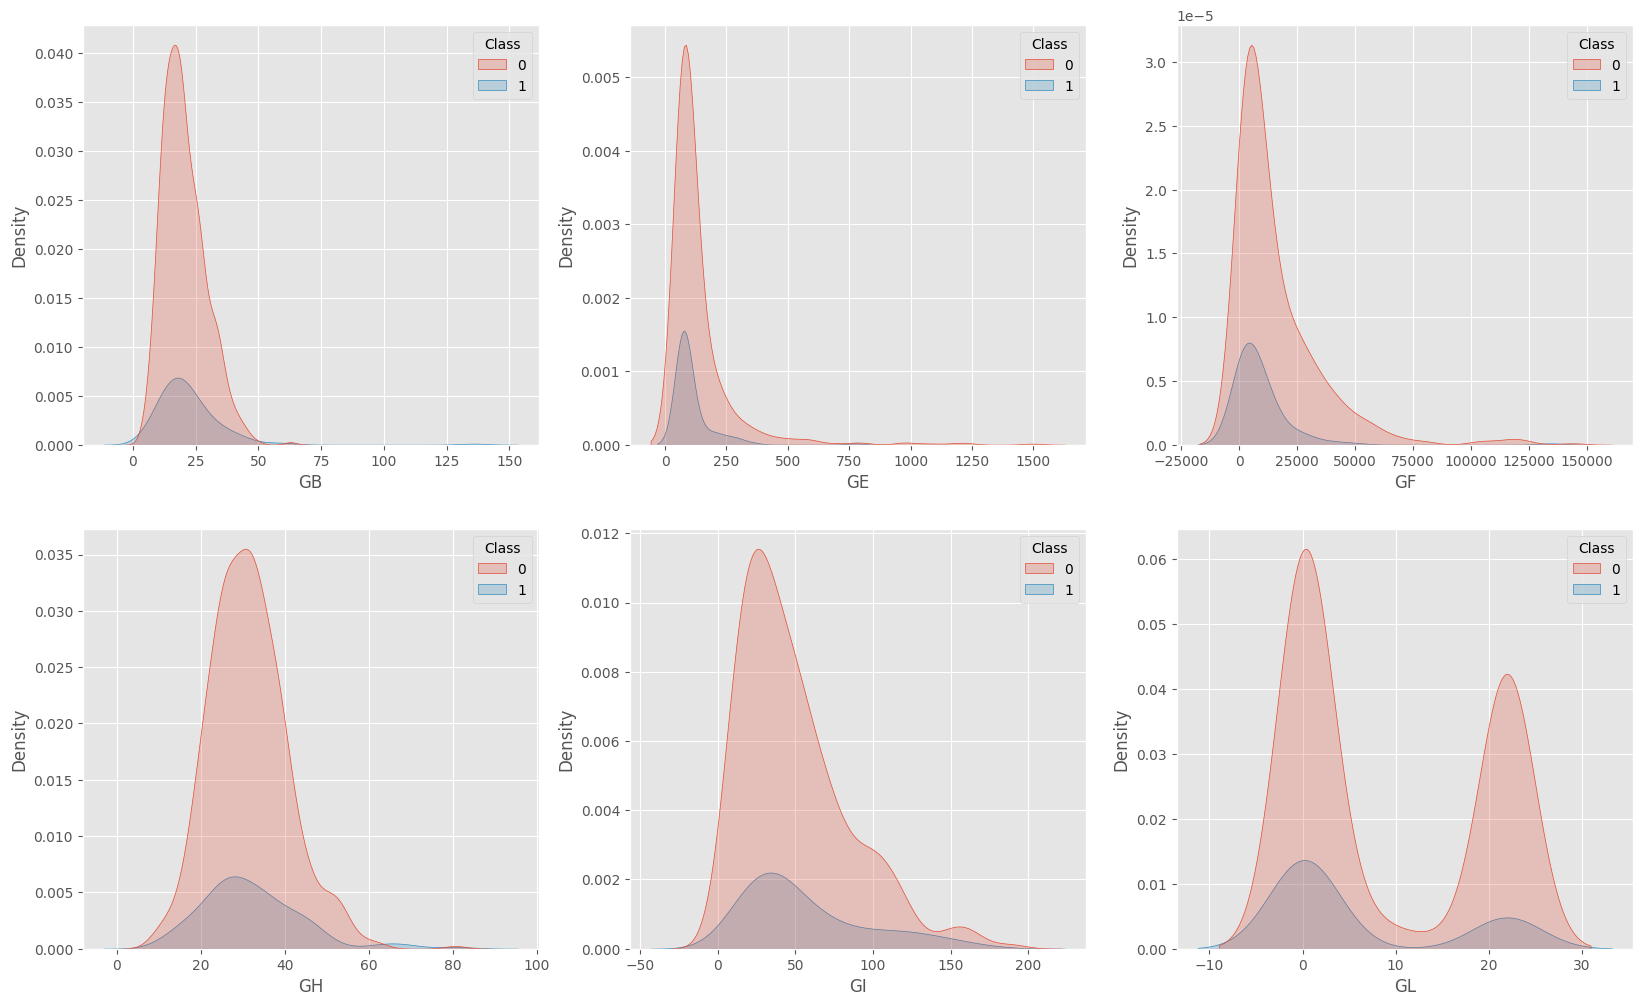

In [16]:
fig, axes = plt.subplots(2, 3, figsize = (20, 12))

sns.kdeplot(ax = axes[0, 0], x = 'GB', hue = 'Class', data = train, fill = True)
sns.kdeplot(ax = axes[0, 1], x = 'GE', hue = 'Class', data = train, fill = True)
sns.kdeplot(ax = axes[0, 2], x = 'GF', hue = 'Class', data = train, fill = True)
sns.kdeplot(ax = axes[1, 0], x = 'GH', hue = 'Class', data = train, fill = True)
sns.kdeplot(ax = axes[1, 1], x = 'GI', hue = 'Class', data = train, fill = True)
sns.kdeplot(ax = axes[1, 2], x = 'GL', hue = 'Class', data = train, fill = True)

**CONCLUSION** - From the above, the distribution of Class for each feature is very similar in 0 and 1.
Hence this is a straightforward behaviour in all features we can say there is a heavy class imbalance

**CHECKING FOR NAns**

In [17]:
train.isnull().sum()

Id        0
AB        0
AF        0
AH        0
AM        0
AR        0
AX        0
AY        0
AZ        0
BC        0
BD        0
BN        0
BP        0
BQ       60
BR        0
BZ        0
CB        2
CC        3
CD        0
CF        0
CH        0
CL        0
CR        0
CS        0
CU        0
CW        0
DA        0
DE        0
DF        0
DH        0
DI        0
DL        0
DN        0
DU        1
DV        0
DY        0
EB        0
EE        0
EG        0
EH        0
EJ        0
EL       60
EP        0
EU        0
FC        1
FD        0
FE        0
FI        0
FL        1
FR        0
FS        2
GB        0
GE        0
GF        0
GH        0
GI        0
GL        1
Class     0
dtype: int64

This shows that there are certain features like, BQ, EL etc.. that are Nans

# Data preparation

In [18]:
from sklearn.impute import SimpleImputer, KNNImputer
X = train.drop(columns=['Class','Id'], inplace=False)
imputer = KNNImputer(n_neighbors=50)
# imputer = SimpleImputer(strategy='mean')
# Impute the missing values in X
X = imputer.fit_transform(X)
X_test = test.drop(columns=['Id'], inplace=False)
X_test = imputer.fit_transform(X_test)
y = train['Class']
print(X.shape)
print("Proportion of 0 labels : " + str( 1- sum(y)/len(y)))

(617, 56)
Proportion of 0 labels : 0.8249594813614263


# MODELLING

There are 617 training points and 58 features. It's not a lot, we might thus need cross-validation to check the generalization abilities, one single validation set might not be enough. Let's now explore the data a bit

In [19]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, accuracy_score
def competition_log_loss(y_true, y_pred):
    # y_true: correct labels 0, 1
    # y_pred: predicted probabilities of class=1
    # Implements the Evaluation equation with w_0 = w_1 = 1.
    # Calculate the number of observations for each class
#     y_pred = y_pred[:, 1]  # Probability of class 1
    N_0 = np.sum(1 - y_true)
    N_1 = np.sum(y_true)
    # Calculate the predicted probabilities for each class
    p_1 = np.clip(y_pred, 1e-15, 1 - 1e-15)
    p_0 = 1 - p_1
    # Calculate the average log loss for each class
    log_loss_0 = -np.sum((1 - y_true) * np.log(p_0)) / N_0
    log_loss_1 = -np.sum(y_true * np.log(p_1)) / N_1
    # return the (not further weighted) average of the averages
    return (log_loss_0 + log_loss_1)/2

def balanced_log_loss(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-15, 1-1e-15)
    nc = np.bincount(y_true)
    w0, w1 = 1/(nc[0]/y_true.shape[0]), 1/(nc[1]/y_true.shape[0])
    balanced_log_loss_score = (-w0/nc[0]*(np.sum(np.where(y_true==0,1,0) * np.log(1-y_pred))) - w1/nc[1]*(np.sum(np.where(y_true!=0,1,0) * np.log(y_pred)))) / (w0+w1)
    return balanced_log_loss_score


scorer = make_scorer(competition_log_loss, needs_proba=True)

In [20]:
import xgboost as xgb
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split, GridSearchCV
import numpy as np


# Define the XGBoost parameters
params = {  'n_estimators': 100,
    'max_depth': 10,
    'learning_rate': 0.05,
    'booster':"gbtree",
}

# Create the XGBoost classifier
xgb_model = xgb.XGBClassifier(**params)

# Define the cross-validation strategy (Stratified K-Fold)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Perform cross-validation and obtain scores
scores = cross_val_score(xgb_model, X, y, cv=cv, scoring=scorer)

# Convert the scores from negative log loss to positive

# Print the mean and standard deviation of the scores
print("Mean cross-validation score: {:.6f} ({:.6f})".format(np.mean(scores), np.std(scores)))

Mean cross-validation score: 0.419344 (0.195178)


# HYPERPARAMETER OPTIMIZATION

In [21]:
import xgboost as xgb
from sklearn.model_selection import cross_val_score
import numpy as np
import optuna

# Define the XGBoost objective function for Optuna
def objective(trial):
    # Define the hyperparameters to be tuned
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': int(trial.suggest_float('max_depth', 3, 10)),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.5),
        'eta': trial.suggest_uniform('eta', 0.01, 0.5),
        'gamma': trial.suggest_uniform('gamma', 0.0, 1.0),
        'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.5, 1.0),
        'subsample': trial.suggest_uniform('subsample', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
    }

    # Create an XGBoost model with the specified hyperparameters
    xgb_model = xgb.XGBClassifier(**params)

    # Define the cross-validation strategy
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    # Perform cross-validation and obtain scores
    scores = cross_val_score(xgb_model, X, y, cv=cv, scoring=scorer)

    # Return the mean score as the objective value for Optuna
    return np.mean(scores)


# Define the study and optimize the objective function
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100)

# Print the best trial and its parameters
best_trial = study.best_trial
print("Best trial:")
print("  Value: {:.6f}".format(best_trial.value))
print("  Params:")
for key, value in best_trial.params.items():
    print("    {}: {}".format(key, value))


[I 2023-05-20 05:43:21,180] A new study created in memory with name: no-name-aef926c3-5f0f-4024-89f1-3d87e83e8308
/tmp/ipykernel_23/3373242024.py:12: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use :func:`~optuna.trial.Trial.suggest_float` instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.5),
/tmp/ipykernel_23/3373242024.py:13: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use :func:`~optuna.trial.Trial.suggest_float` instead.
  'eta': trial.suggest_uniform('eta', 0.01, 0.5),
/tmp/ipykernel_23/3373242024.py:14: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use :func:`~optuna.trial.Trial.suggest_float` instead.
  'gamm

Best trial:
  Value: 0.345064
  Params:
    n_estimators: 185
    max_depth: 3.6900953694427603
    learning_rate: 0.13827194691418282
    eta: 0.405674955131706
    gamma: 0.22227631054922126
    colsample_bytree: 0.6015273194835291
    subsample: 0.6481396210802199
    min_child_weight: 4


# SUBMISSION

In [22]:
# Fit the model on the training data
xgb_model.fit(X, y)

# Output the predicted probabilities for each class
y_proba = xgb_model.predict_proba(X_test)
y_proba_0 = y_proba[:, 0]
y_proba_1 = y_proba[:, 1]

In [23]:
# Create a DataFrame to store the submission data
submission_df = pd.DataFrame({'Id': test['Id'], 'class_0': y_proba[:, 0], 'class_1': y_proba[:, 1]})

# Save the submission DataFrame to a CSV file
submission_df.to_csv('submission.csv', index=False)